# OCR, Face Recognition, Pose Estimation & Depth

## OCR Optical Character Recognition

### Pipeline
```
Image → Text Detection → Text Recognition → Post-processing
```

### Text Detection Models

| Model | Approach | Notes |
|-------|----------|-------|
| EAST | Regression + classification | Fast, anchor-free |
| DBNet | Differentiable Binarization | SOTA accuracy |
| CRAFT | Region/affinity scores | Good for curved text |
| TextBPN | Boundary proposal | Arbitrary shapes |

**Differentiable Binarization (DB)** threshold map:
$$\hat{B}_{i,j} = \frac{1}{1 + e^{-k(P_{i,j} - T_{i,j})}}$$

where $P$ = probability map, $T$ = adaptive threshold map, $k=50$.

### Text Recognition CRNN

Architecture: CNN feature extractor → Bidirectional LSTM → CTC decoder

**CTC (Connectionist Temporal Classification) Loss**:
$$p(l|y) = \sum_{\pi \in \mathcal{B}^{-1}(l)} p(\pi|y)$$

where $\mathcal{B}$ is the CTC collapsing function (remove blanks and repeated chars).

$$\mathcal{L}_{CTC} = -\ln p(l|y)$$

Modern recognition uses **TrOCR** (Transformer-based OCR) or **STR** (Scene Text Recognition) transformer.

---

## Face Detection & Recognition

### Face Detection
- **MTCNN**: cascade of three networks (P-Net, R-Net, O-Net) for multi-scale detection
- **RetinaFace**: single-stage, 5 landmark detection + bounding box
- **YOLO5Face**: YOLOv5 adapted for face detection

### Face Recognition

**ArcFace Loss** (additive angular margin):
$$L = -\frac{1}{N}\sum_{i=1}^{N} \log \frac{e^{s(\cos(\theta_{y_i}+m))}}{e^{s(\cos(\theta_{y_i}+m))} + \sum_{j \neq y_i} e^{s\cos\theta_j}}$$

where $m$ = angular margin (typically 0.5), $s$ = scale (typically 64).

**CosFace Loss** (cosine margin):
$$L = -\frac{1}{N}\sum \log \frac{e^{s(\cos\theta_{y_i}-m)}}{e^{s(\cos\theta_{y_i}-m)} + \sum_{j\neq y_i}e^{s\cos\theta_j}}$$

**FaceNet Loss** (triplet loss):
$$L = \sum_i^N \left[||f(x_i^a) - f(x_i^p)||^2 - ||f(x_i^a) - f(x_i^n)||^2 + \alpha\right]_+$$

where $a$=anchor, $p$=positive (same person), $n$=negative (different person), $\alpha$=margin.

---

## Pose Estimation

### Human Pose Estimation

**Heatmap-based approach** (most common):
- Predict a heatmap $H_k \in \mathbb{R}^{H\times W}$ for each of $K$ keypoints
- Target: 2D Gaussian centered at keypoint location $p_k$:
$$H_k(x,y) = \exp\left(-\frac{(x-p_k^x)^2 + (y-p_k^y)^2}{2\sigma^2}\right)$$
- Loss: MSE between predicted and target heatmaps

**Models**:
- SimpleBaseline (ResNet + deconv head)
- HRNet (high-resolution representation)
- ViTPose (ViT backbone for pose)
- RTMPose (real-time, production-grade)
- OpenPose: Part Affinity Fields (PAFs) for bottom-up multi-person

**COCO Keypoints**: 17 joints (nose, eyes, ears, shoulders, elbows, wrists, hips, knees, ankles)

**OKS (Object Keypoint Similarity)**:
$$OKS = \frac{\sum_i \exp\left(-\frac{d_i^2}{2s^2k_i^2}\right) \delta(v_i>0)}{\sum_i \delta(v_i>0)}$$

---

## Depth Estimation

**Monocular depth estimation**: predict depth from single RGB image.

**Scale-invariant loss** (used in MiDaS/DPT):
$$L_{si} = \frac{1}{n}\sum_i d_i^2 - \frac{1}{n^2}\left(\sum_i d_i\right)^2$$

where $d_i = \log\hat{y}_i - \log y_i$.

**Models**:
- MiDaS: multi-dataset training for zero-shot generalization
- DPT (Dense Prediction Transformer): ViT backbone for dense tasks
- Depth Anything V2 (2024): foundation model for depth
- UniDepth: metric depth without scale ambiguity


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# CRNN Architecture for Text Recognition
# ============================================================

class CRNN(nn.Module):
    """
    CRNN: CNN + Bidirectional LSTM + CTC
    Input: (B, 1, 32, W) grayscale, fixed height 32
    """
    def __init__(self, num_chars=38, hidden_size=256):  # 38 = 26 letters + 10 digits + blank + space
        super().__init__()

        # CNN feature extractor (VGG-like)
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d((2,1), (2,1)),  # Only pool height
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d((2,1), (2,1)),
            nn.Conv2d(512, 512, 2), nn.ReLU(),  # 1x1 feature maps
        )

        # RNN sequence modeling
        self.rnn = nn.Sequential(
            nn.LSTM(512, hidden_size, bidirectional=True, batch_first=True),
        )
        self.rnn2 = nn.LSTM(hidden_size*2, hidden_size, bidirectional=True, batch_first=True)

        # Output projection to character classes
        self.fc = nn.Linear(hidden_size * 2, num_chars)

    def forward(self, x):
        # CNN features: (B, C, H, W)
        features = self.cnn(x)              # (B, 512, 1, W')
        features = features.squeeze(2)      # (B, 512, W')
        features = features.permute(0, 2, 1)  # (B, W', 512) time steps

        # RNN
        rnn_out, _ = self.rnn[0](features)    # (B, W', 512)
        rnn_out2, _ = self.rnn2(rnn_out)      # (B, W', 512)

        # Character logits
        out = self.fc(rnn_out2)               # (B, W', num_chars)
        out = out.permute(1, 0, 2)            # (W', B, num_chars) CTC format
        return out


crnn = CRNN(num_chars=38, hidden_size=256)
x = torch.randn(4, 1, 32, 128)  # Batch of 4 text images
out = crnn(x)
print(f'Input: {x.shape}')
print(f'Output (T, B, C): {out.shape}')  # (T=time_steps, B=batch, C=chars)
params = sum(p.numel() for p in crnn.parameters())
print(f'Parameters: {params/1e6:.2f}M')

Input: torch.Size([4, 1, 32, 128])
Output (T, B, C): torch.Size([31, 4, 38])
Parameters: 8.72M


In [3]:
# CTC Loss example
# Input: log-softmax of CRNN output
T, B, C = 32, 4, 38  # Time steps, batch, classes
log_probs = torch.randn(T, B, C).log_softmax(dim=2)
targets   = torch.randint(1, C, (B, 5))  # Target sequences (length 5 each)
input_lengths  = torch.full((B,), T, dtype=torch.long)
target_lengths = torch.full((B,), 5, dtype=torch.long)

ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)
loss = ctc_loss(log_probs, targets, input_lengths, target_lengths)
print(f'CTC Loss: {loss.item():.4f}')

CTC Loss: 20.6012


In [4]:
# ============================================================
# PaddleOCR State-of-the-Art OCR Library
# ============================================================
# pip install paddlepaddle paddleocr

paddle_ocr_code = '''
from paddleocr import PaddleOCR
import numpy as np
from PIL import Image

# Initialize downloads models automatically
ocr = PaddleOCR(
    use_angle_cls=True,   # Detect rotated text
    lang='en',            # Language ('ch', 'en', 'fr', 'de', etc.)
    use_gpu=True
)

# Run on image
result = ocr.ocr('document.jpg', cls=True)

for line in result[0]:
    bbox, (text, confidence) = line
    print(f"Text: {text:30s} | Conf: {confidence:.3f} | Box: {bbox}")

# Visualize
from paddleocr import draw_ocr
image = Image.open('document.jpg').convert('RGB')
boxes  = [line[0] for line in result[0]]
txts   = [line[1][0] for line in result[0]]
scores = [line[1][1] for line in result[0]]
vis = draw_ocr(image, boxes, txts, scores, font_path='./fonts/en_standard.ttf')
Image.fromarray(vis).save('result.jpg')
'''

easyocr_code = '''
import easyocr

reader = easyocr.Reader(['en', 'fr'], gpu=True)
result = reader.readtext('document.jpg')

for (bbox, text, prob) in result:
    print(f"{text:30s} | prob={prob:.3f}")

# Just get text
texts = reader.readtext('document.jpg', detail=0)
print(" ".join(texts))
'''

print('PaddleOCR Usage:'); print(paddle_ocr_code)
print('\nEasyOCR Usage:'); print(easyocr_code)

PaddleOCR Usage:

from paddleocr import PaddleOCR
import numpy as np
from PIL import Image

# Initialize downloads models automatically
ocr = PaddleOCR(
    use_angle_cls=True,   # Detect rotated text
    lang='en',            # Language ('ch', 'en', 'fr', 'de', etc.)
    use_gpu=True
)

# Run on image
result = ocr.ocr('document.jpg', cls=True)

for line in result[0]:
    bbox, (text, confidence) = line
    print(f"Text: {text:30s} | Conf: {confidence:.3f} | Box: {bbox}")

# Visualize
from paddleocr import draw_ocr
image = Image.open('document.jpg').convert('RGB')
boxes  = [line[0] for line in result[0]]
txts   = [line[1][0] for line in result[0]]
scores = [line[1][1] for line in result[0]]
vis = draw_ocr(image, boxes, txts, scores, font_path='./fonts/en_standard.ttf')
Image.fromarray(vis).save('result.jpg')


EasyOCR Usage:

import easyocr

reader = easyocr.Reader(['en', 'fr'], gpu=True)
result = reader.readtext('document.jpg')

for (bbox, text, prob) in result:
    print(f"{text:30s}

ArcFace Loss: 41.2540


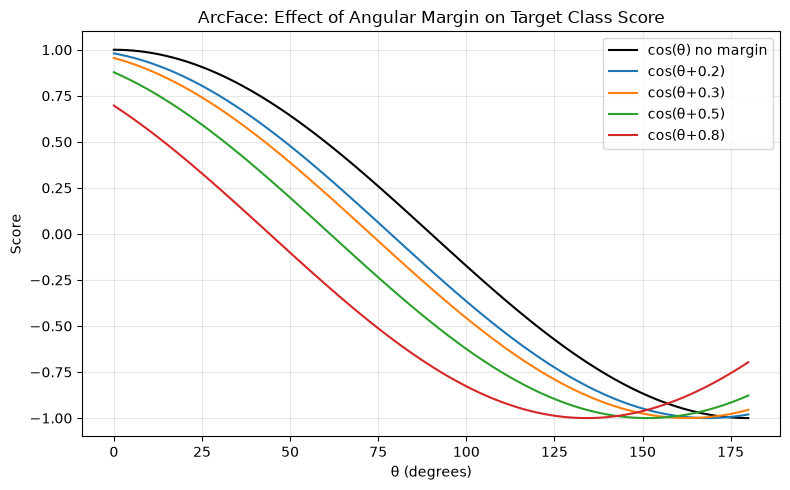

In [5]:
# ============================================================
# ArcFace Loss Implementation
# ============================================================

class ArcFaceLoss(nn.Module):
    """
    ArcFace: Additive Angular Margin Loss for Face Recognition.
    Paper: https://arxiv.org/abs/1801.07698
    """
    def __init__(self, in_features, num_classes, scale=64.0, margin=0.5):
        super().__init__()
        self.scale  = scale
        self.margin = margin
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        # Normalize embeddings and weights
        emb_norm = F.normalize(embeddings)
        w_norm   = F.normalize(self.weight)

        # Cosine similarity
        cos_theta = F.linear(emb_norm, w_norm)           # (B, num_classes)
        cos_theta = cos_theta.clamp(-1, 1)

        # Add angular margin to target class
        theta = torch.acos(cos_theta)
        one_hot = torch.zeros_like(cos_theta).scatter_(1, labels.view(-1,1), 1)
        # Add margin m to the angle of the true class
        target_cos = torch.cos(theta + self.margin)
        output = cos_theta * (1 - one_hot) + target_cos * one_hot

        # Scale and compute cross-entropy
        output = output * self.scale
        loss = F.cross_entropy(output, labels)
        return loss


import torch.nn.functional as F

# Test
arcface = ArcFaceLoss(in_features=512, num_classes=1000, scale=64, margin=0.5)
embeddings = torch.randn(32, 512)     # 32 face embeddings of dim 512
labels     = torch.randint(0, 1000, (32,))
loss = arcface(embeddings, labels)
print(f'ArcFace Loss: {loss.item():.4f}')

# Visualize effect of margin
theta = np.linspace(0, np.pi, 100)
cos_theta = np.cos(theta)

plt.figure(figsize=(8, 5))
plt.plot(theta * 180/np.pi, cos_theta, 'k-', label='cos(θ) no margin')
for m in [0.2, 0.3, 0.5, 0.8]:
    plt.plot(theta * 180/np.pi, np.cos(theta + m), label=f'cos(θ+{m})')
plt.xlabel('θ (degrees)'); plt.ylabel('Score')
plt.title('ArcFace: Effect of Angular Margin on Target Class Score')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [6]:
# ============================================================
# MediaPipe Pose, Face, Hands
# ============================================================
# pip install mediapipe

mediapipe_code = '''
import mediapipe as mp
import cv2

mp_drawing = mp.solutions.drawing_utils
mp_pose    = mp.solutions.pose
mp_hands   = mp.solutions.hands
mp_face    = mp.solutions.face_detection

# ---- Pose Estimation ----
cap = cv2.VideoCapture(0)
with mp_pose.Pose(min_detection_confidence=0.5,
                  min_tracking_confidence=0.5) as pose:
    while cap.isOpened():
        ret, frame = cap.read()
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(image)

        if results.pose_landmarks:
            # 33 landmarks: nose, shoulders, elbows, wrists, hips, knees, ankles, etc.
            for idx, landmark in enumerate(results.pose_landmarks.landmark):
                print(f"Landmark {idx}: x={landmark.x:.3f}, y={landmark.y:.3f}, z={landmark.z:.3f}")

            # Draw on image
            mp_drawing.draw_landmarks(
                image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS
            )

# ---- Hands ----
with mp_hands.Hands(max_num_hands=2) as hands:
    results = hands.process(image)
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            # 21 landmarks per hand
            mp_drawing.draw_landmarks(image, hand_landmarks, mp_hands.HAND_CONNECTIONS)

# ---- Face Detection ----
with mp_face.FaceDetection(min_detection_confidence=0.5) as fd:
    results = fd.process(image)
    if results.detections:
        for detection in results.detections:
            bbox = detection.location_data.relative_bounding_box
            print(f"Face: x={bbox.xmin:.3f}, y={bbox.ymin:.3f}")
'''
print('MediaPipe Code:')
print(mediapipe_code)

MediaPipe Code:

import mediapipe as mp
import cv2

mp_drawing = mp.solutions.drawing_utils
mp_pose    = mp.solutions.pose
mp_hands   = mp.solutions.hands
mp_face    = mp.solutions.face_detection

# ---- Pose Estimation ----
cap = cv2.VideoCapture(0)
with mp_pose.Pose(min_detection_confidence=0.5,
                  min_tracking_confidence=0.5) as pose:
    while cap.isOpened():
        ret, frame = cap.read()
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(image)

        if results.pose_landmarks:
            # 33 landmarks: nose, shoulders, elbows, wrists, hips, knees, ankles, etc.
            for idx, landmark in enumerate(results.pose_landmarks.landmark):
                print(f"Landmark {idx}: x={landmark.x:.3f}, y={landmark.y:.3f}, z={landmark.z:.3f}")

            # Draw on image
            mp_drawing.draw_landmarks(
                image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS
            )

# ---- Hands ----
with mp_hands.Hands(

In [7]:
# ============================================================
# Depth Anything V2 Usage
# ============================================================
# pip install transformers

depth_code = '''
from transformers import pipeline
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Depth Anything V2 Foundation model for monocular depth
pipe = pipeline(
    task="depth-estimation",
    model="depth-anything/Depth-Anything-V2-Large-hf"
)

image = Image.open("scene.jpg")
depth = pipe(image)["depth"]

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1); plt.imshow(image); plt.title("RGB"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(depth, cmap="inferno"); plt.title("Depth"); plt.axis("off")
plt.tight_layout(); plt.show()

# MiDaS multi-dataset trained depth estimation
import torch
midas = torch.hub.load("intel-isl/MiDaS", "DPT_Large")
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = midas_transforms.dpt_transform

import cv2
img = cv2.imread("scene.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
input_batch = transform(img).unsqueeze(0)

with torch.no_grad():
    prediction = midas(input_batch)
    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img.shape[:2],
        mode="bicubic", align_corners=False,
    ).squeeze()

depth_map = prediction.numpy()
'''
print('Depth Estimation Usage:')
print(depth_code)

Depth Estimation Usage:

from transformers import pipeline
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Depth Anything V2 Foundation model for monocular depth
pipe = pipeline(
    task="depth-estimation",
    model="depth-anything/Depth-Anything-V2-Large-hf"
)

image = Image.open("scene.jpg")
depth = pipe(image)["depth"]

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1); plt.imshow(image); plt.title("RGB"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(depth, cmap="inferno"); plt.title("Depth"); plt.axis("off")
plt.tight_layout(); plt.show()

# MiDaS multi-dataset trained depth estimation
import torch
midas = torch.hub.load("intel-isl/MiDaS", "DPT_Large")
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = midas_transforms.dpt_transform

import cv2
img = cv2.imread("scene.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
input_batch = transform(img).unsqueeze(0)

with torch.no_grad():
    prediction = midas(input_batch)
    predic

In [8]:
# ============================================================
# Face Recognition Pipeline with InsightFace
# ============================================================
# pip install insightface onnxruntime

insightface_code = '''
import insightface
from insightface.app import FaceAnalysis
import numpy as np
import cv2

# Initialize downloads models automatically
app = FaceAnalysis(providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
app.prepare(ctx_id=0, det_size=(640, 640))

# Analyze faces in image
img = cv2.imread("photo.jpg")
faces = app.get(img)

for face in faces:
    print(f"BBox: {face.bbox}")
    print(f"Embedding: {face.embedding.shape}")   # (512,) ArcFace embedding
    print(f"Age: {face.age}, Gender: {'M' if face.gender==1 else 'F'}")
    print(f"5 Landmarks: {face.kps}")

# Face verification: compare two faces
def verify_faces(face1_img, face2_img, threshold=0.6):
    faces1 = app.get(face1_img)
    faces2 = app.get(face2_img)
    if not faces1 or not faces2:
        return False, 0.0
    emb1 = faces1[0].embedding / np.linalg.norm(faces1[0].embedding)
    emb2 = faces2[0].embedding / np.linalg.norm(faces2[0].embedding)
    similarity = float(np.dot(emb1, emb2))
    return similarity > threshold, similarity

same_person, score = verify_faces(img1, img2)
print(f"Same person: {same_person}, Score: {score:.4f}")
'''
print('InsightFace (ArcFace) Usage:')
print(insightface_code)

InsightFace (ArcFace) Usage:

import insightface
from insightface.app import FaceAnalysis
import numpy as np
import cv2

# Initialize downloads models automatically
app = FaceAnalysis(providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
app.prepare(ctx_id=0, det_size=(640, 640))

# Analyze faces in image
img = cv2.imread("photo.jpg")
faces = app.get(img)

for face in faces:
    print(f"BBox: {face.bbox}")
    print(f"Embedding: {face.embedding.shape}")   # (512,) ArcFace embedding
    print(f"Age: {face.age}, Gender: {'M' if face.gender==1 else 'F'}")
    print(f"5 Landmarks: {face.kps}")

# Face verification: compare two faces
def verify_faces(face1_img, face2_img, threshold=0.6):
    faces1 = app.get(face1_img)
    faces2 = app.get(face2_img)
    if not faces1 or not faces2:
        return False, 0.0
    emb1 = faces1[0].embedding / np.linalg.norm(faces1[0].embedding)
    emb2 = faces2[0].embedding / np.linalg.norm(faces2[0].embedding)
    similarity = float(np.dot(emb1, emb2

## Additional Learning Resources

### Papers
- [CRNN: An End-to-End Trainable Network for OCR](https://arxiv.org/abs/1507.05717) Shi et al. 2015
- [DBNet: Real-time Scene Text Detection with Differentiable Binarization](https://arxiv.org/abs/1911.08947) Liao et al. 2020
- [TrOCR: Transformer-based OCR](https://arxiv.org/abs/2109.10282) Li et al. 2021
- [MTCNN: Joint Face Detection and Alignment](https://arxiv.org/abs/1604.02878) Zhang et al. 2016
- [RetinaFace: Single-stage Dense Face Localisation](https://arxiv.org/abs/1905.00641) Deng et al. 2019
- [ArcFace: Additive Angular Margin Loss](https://arxiv.org/abs/1801.07698) Deng et al. 2019
- [FaceNet: A Unified Embedding for Face Recognition](https://arxiv.org/abs/1503.03832) Schroff et al. 2015
- [OpenPose: Realtime Multi-Person 2D Pose Estimation](https://arxiv.org/abs/1812.08008) Cao et al. 2018
- [HRNet: Deep High-Resolution Representation Learning](https://arxiv.org/abs/1902.09212) Wang et al. 2019
- [ViTPose: Simple Vision Transformer Baselines for Pose Estimation](https://arxiv.org/abs/2204.12484) Xu et al. 2022
- [MiDaS: Towards Robust Monocular Depth Estimation](https://arxiv.org/abs/1907.01341) Ranftl et al. 2020
- [DPT: Vision Transformers for Dense Prediction](https://arxiv.org/abs/2103.13413) Ranftl et al. 2021
- [Depth Anything V2](https://arxiv.org/abs/2406.09414) Yang et al. 2024

### Libraries & Tools
- [PaddleOCR](https://github.com/PaddlePaddle/PaddleOCR) State-of-the-art OCR
- [EasyOCR](https://github.com/JaidedAI/EasyOCR) Ready-to-use OCR
- [TrOCR](https://huggingface.co/microsoft/trocr-base-printed) Transformer OCR
- [InsightFace](https://github.com/deepinsight/insightface) ArcFace face recognition
- [MediaPipe](https://developers.google.com/mediapipe) Google's pose/hand/face pipeline
- [MMPose](https://mmpose.readthedocs.io/) OpenMMLab pose estimation
- [RTMPose](https://github.com/open-mmlab/mmpose/tree/main/projects/rtmpose) Real-time pose estimation
